In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
base_temperature = 10
temperature_df = pd.read_csv('../docs/temperature.csv', parse_dates=['datetime'])

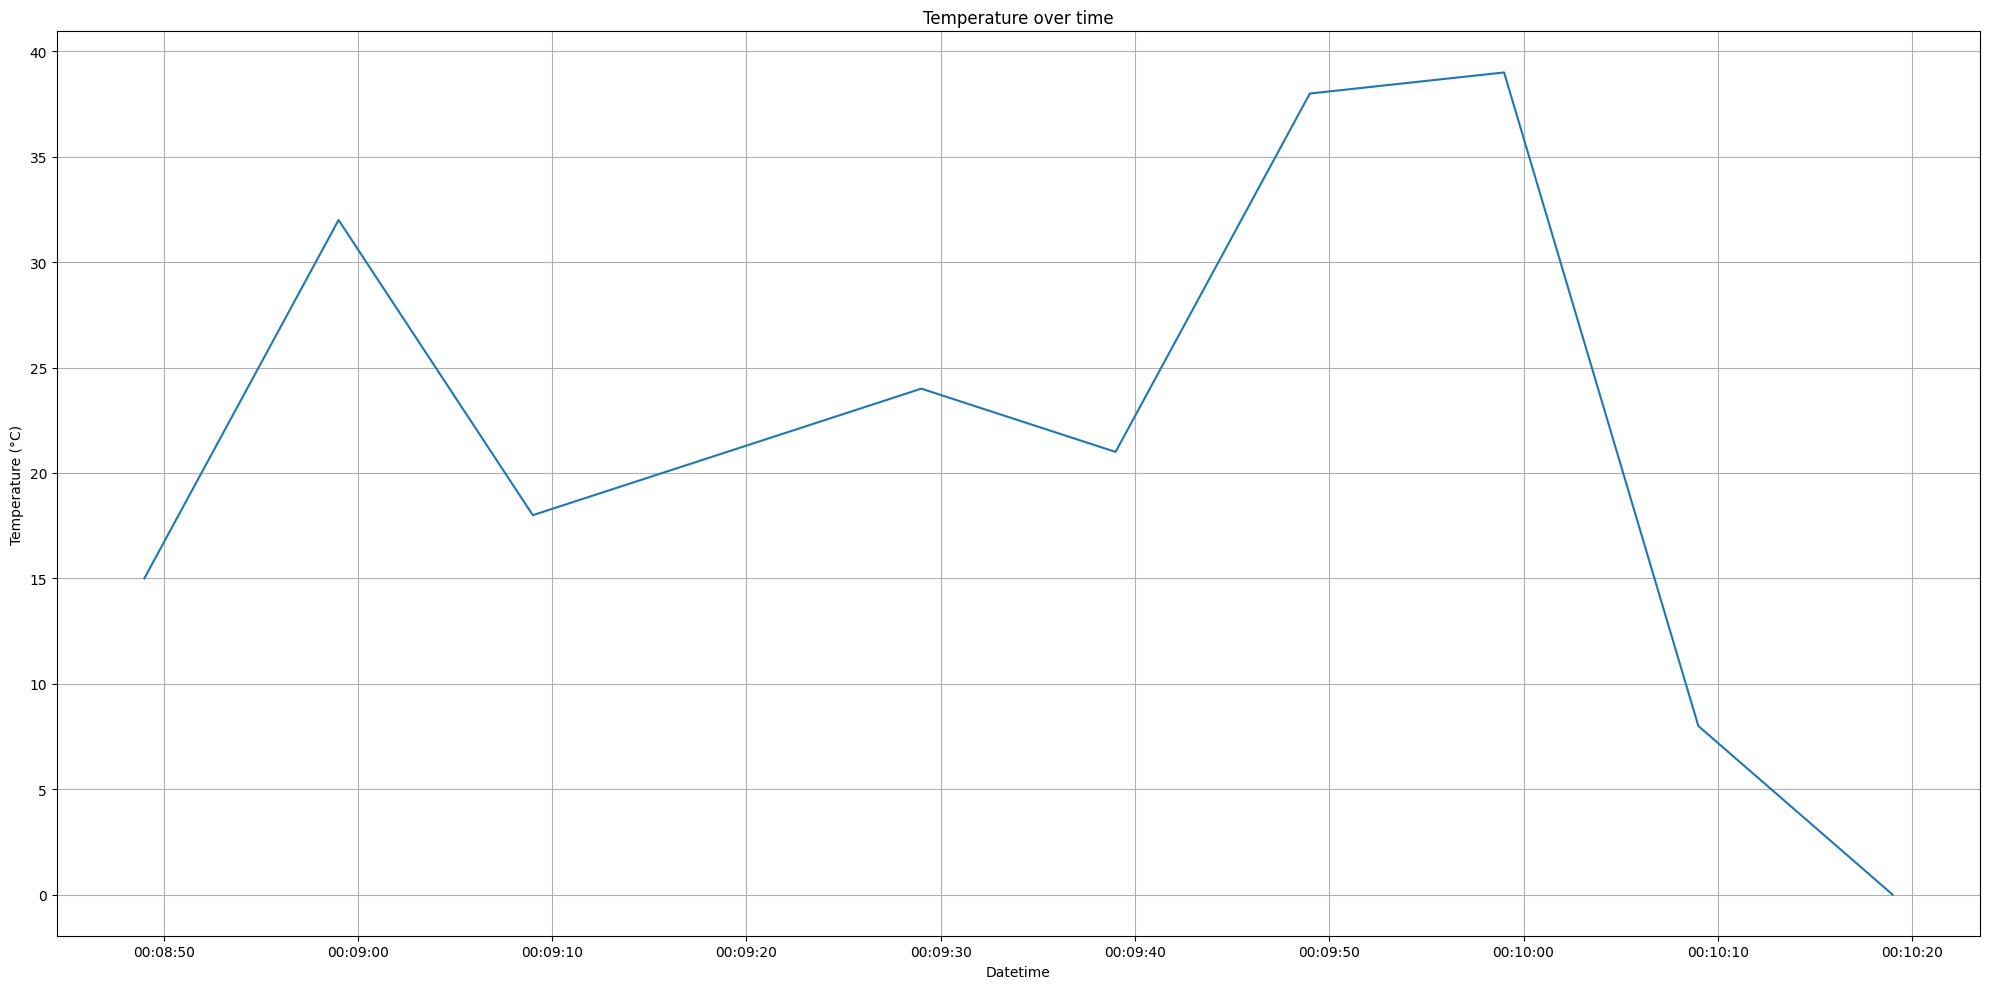

In [4]:
plt.figure(figsize=(20, 10))
plt.plot(temperature_df['datetime'], temperature_df['temperature'])
plt.title("Temperature over time")
plt.xlabel("Datetime")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation='horizontal')
plt.grid(True)
plt.tight_layout()

In [6]:
# Convert datetimes to pure dates so we can group by the date
temperature_df['datetime'] = pd.to_datetime(temperature_df['datetime']).dt.date

# Group the data by date so it can be analyzed by date
data_by_date = temperature_df.groupby('datetime')

# Get the minimum and maximum temperatures for each date
min_by_date = data_by_date.min()
max_by_date = data_by_date.max()

# Join the min and max temperatures into one dataframe and flatten it
min_max_by_date = min_by_date.join(max_by_date, on='datetime', lsuffix='_min', rsuffix='_max')
min_max_by_date = min_max_by_date.reset_index()

In [7]:
def calculate_gdd(row):
    return ((row['temperature_max'] + row['temperature_min']) / 2) - base_temperature

In [9]:
# Calculate the GDD for each row
min_max_by_date['gdd'] = min_max_by_date.apply (lambda row: calculate_gdd(row), axis=1)

# Print the results
print(min_max_by_date[['datetime', 'gdd']].to_string(index=False))

  datetime  gdd
2025-09-28  9.5
